In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Binary Proxy Metrics
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

# Model Explainability
import shap
import lime
import lime.lime_tabular

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

C:\Users\SAUL\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# 1. LOAD DATA
df_raw = pd.read_csv('Oxford_Battery_Degradation_Dataset.csv')
df_raw.columns = df_raw.columns.str.strip()
df_raw = df_raw.dropna().copy()

# 2. ENFORCE FIXED FEATURE ORDER
TARGET = 'SOH_capacity'

X = df_raw[df_raw.columns.difference([TARGET, 'Cell_ID'])].copy()
y = df_raw[TARGET].copy()

# 3. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"✓ Data loaded successfully. Features strictly ordered: {X.columns.tolist()}")
print(f"✓ Training set shape: {X_train.shape} | Testing set shape: {X_test.shape}")

✓ Data loaded successfully. Features strictly ordered: ['avg_temp', 'avg_voltage', 'charge_cycles', 'max_factory_cap']
✓ Training set shape: (415, 4) | Testing set shape: (104, 4)


--- Launching Exploratory Data Analysis ---
✓ EDA complete. Performance graphs saved locally.


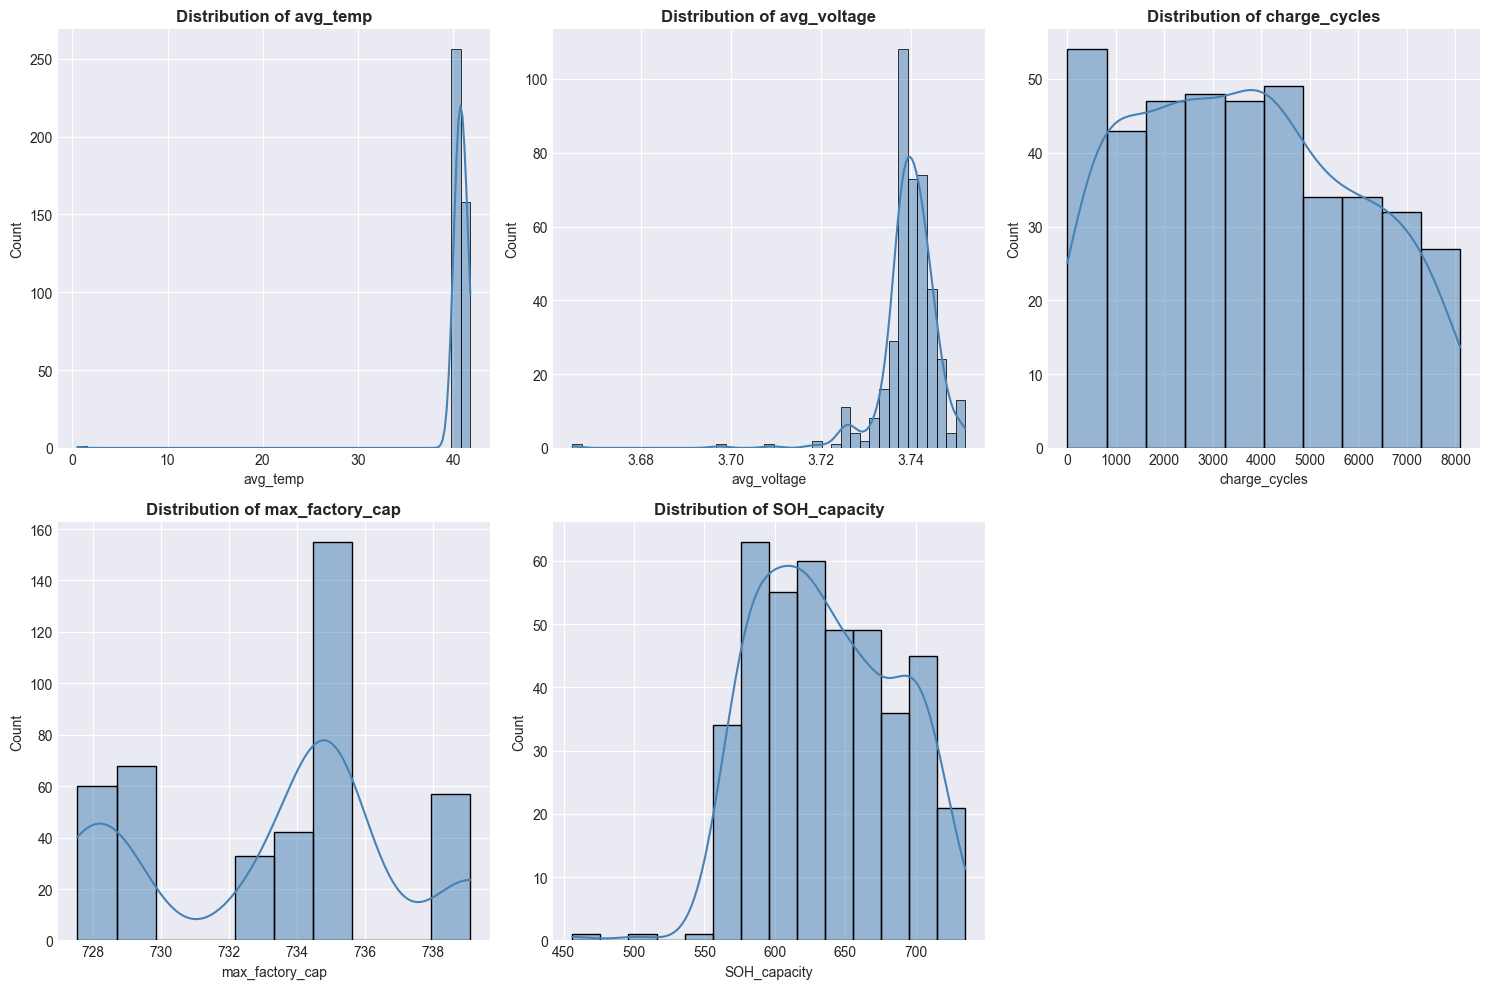

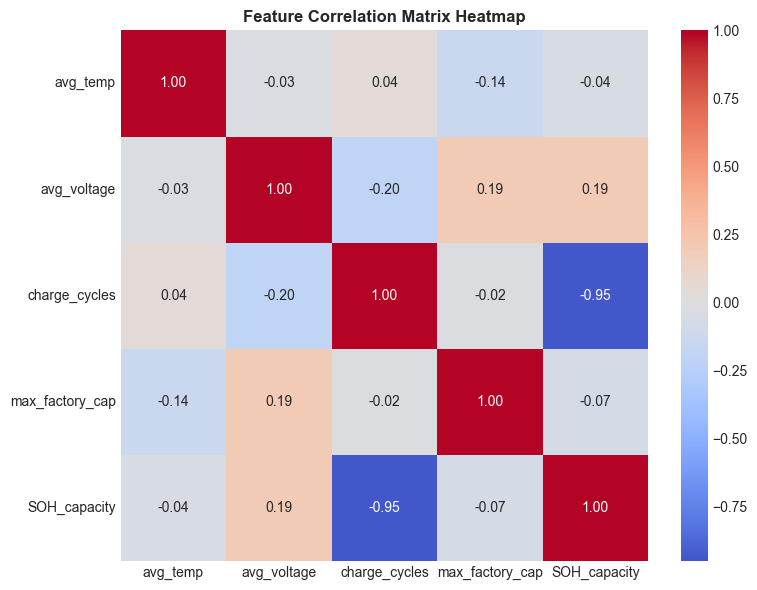

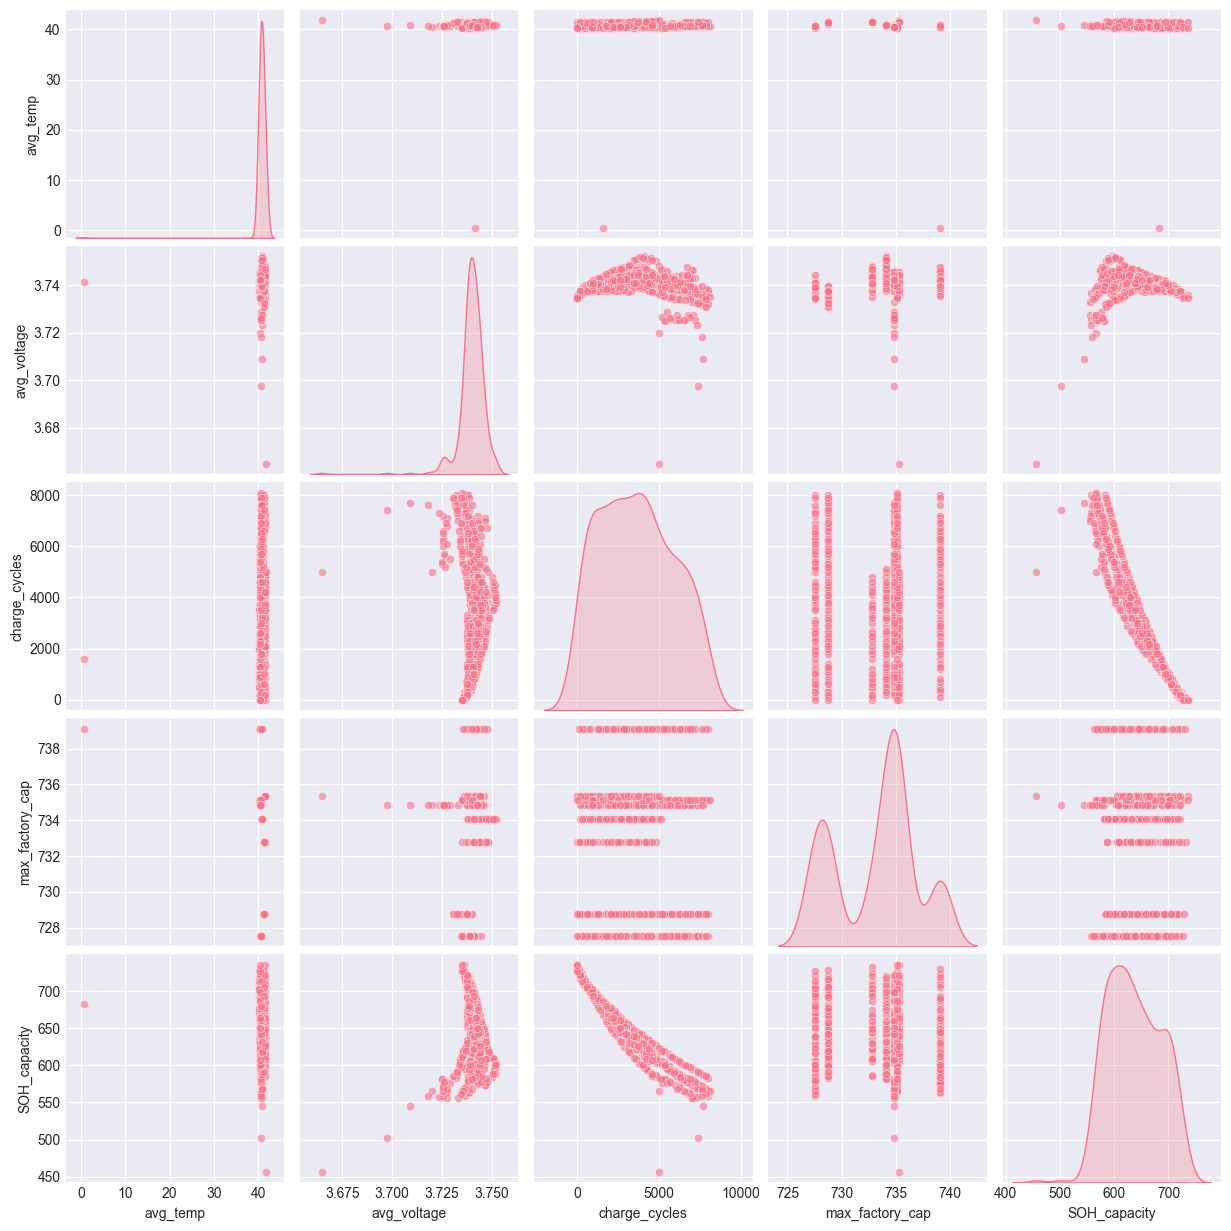

In [9]:
print("--- Launching Exploratory Data Analysis ---")

# Merge features and target temporarily for visualization
df_eda = pd.concat([X_train, y_train], axis=1)

# 1. Distribution Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for idx, col in enumerate(df_eda.columns):
    sns.histplot(df_eda[col], kde=True, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
for ax in axes[len(df_eda.columns):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')

# 2. Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_eda.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')

# 3. Pairplot
pair_grid = sns.pairplot(df_eda, diag_kind='kde', plot_kws={'alpha': 0.6})
pair_grid.savefig('eda_pairplot.png', dpi=150, bbox_inches='tight')

print("✓ EDA complete. Performance graphs saved locally.")

In [10]:
print("--- Phase 1: Broad Model Exploration via RandomizedSearchCV ---")

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# Define candidates and random hyperparameter spaces
models_dict = {
    'Ridge': Ridge(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

param_distributions = {
    'Ridge': {
        'regressor__alpha': np.logspace(-3, 3, 20)
    },
    'RandomForest': {
        'regressor__n_estimators': [50, 100, 200],
        'regressor__max_depth': [3, 5, 10, None],
        'regressor__min_samples_split': [2, 5, 10]
    },
    'GradientBoosting': {
        'regressor__n_estimators': [50, 100, 150],
        'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'regressor__max_depth': [3, 5, 7]
    }
}

search_results = {}

for name, model in models_dict.items():
    # Construct complete isolated pipeline stage
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])
    
    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions[name],
        n_iter=10,
        cv=cv_strategy,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        random_state=42,
        error_score='raise'
    )
    
    random_search.fit(X_train, y_train)
    search_results[name] = {
        'best_score': -random_search.best_score_,
        'best_params': random_search.best_params_
    }
    print(f"↳ {name} Best Validation MAE: {search_results[name]['best_score']:.6f}")

# Select best overall baseline candidate model
best_model_name = min(search_results, key=lambda k: search_results[k]['best_score'])
print(f"\n✓ Best Model selected for deep tuning: {best_model_name}")

--- Phase 1: Broad Model Exploration via RandomizedSearchCV ---
↳ Ridge Best Validation MAE: 10.525424
↳ RandomForest Best Validation MAE: 3.168049
↳ GradientBoosting Best Validation MAE: 2.620370

✓ Best Model selected for deep tuning: GradientBoosting


In [11]:
print(f"--- Phase 2: Hyperparameter Fine-Tuning ({best_model_name}) ---")

# Narrow down grids dynamically based on the winner
if best_model_name == 'GradientBoosting':
    grid_params = {
        'regressor__n_estimators': [100, 150],
        'regressor__learning_rate': [0.05, 0.07, 0.1],
        'regressor__max_depth': [5, 7]
    }
elif best_model_name == 'RandomForest':
    grid_params = {
        'regressor__n_estimators': [150, 200],
        'regressor__max_depth': [8, 10, 12],
        'regressor__min_samples_split': [2, 4]
    }
else:
    grid_params = {
        'regressor__alpha': [0.1, 1.0, 10.0]
    }

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', models_dict[best_model_name])
])

grid_search = GridSearchCV(
    estimator=final_pipeline,
    param_grid=grid_params,
    cv=cv_strategy,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_

print(f"✓ Grid Search Complete.")
print(f"↳ Optimized Hyperparameters: {grid_search.best_params_}")
print(f"↳ Tuned Cross-Validation MAE: {-grid_search.best_score_:.6f}")

--- Phase 2: Hyperparameter Fine-Tuning (GradientBoosting) ---
✓ Grid Search Complete.
↳ Optimized Hyperparameters: {'regressor__learning_rate': 0.07, 'regressor__max_depth': 5, 'regressor__n_estimators': 150}
↳ Tuned Cross-Validation MAE: 2.558097



--- Final Test Set Metrics Summary ---
MAE  : 1.60316
RMSE : 2.62985
R²   : 0.99759
MAPE : 0.261%


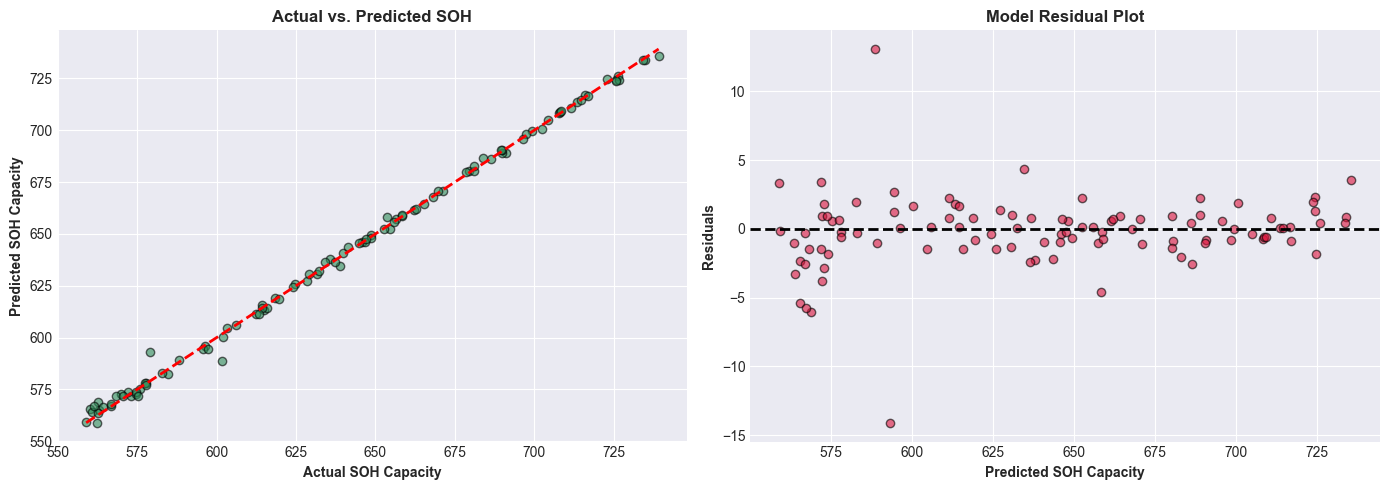

In [12]:
# Inference on testing subset
y_pred = best_pipeline.predict(X_test)
residuals = y_test - y_pred

# Compute Regression Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs(residuals / y_test)) * 100

print("\n--- Final Test Set Metrics Summary ---")
print(f"MAE  : {mae:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"R²   : {r2:.5f}")
print(f"MAPE : {mape:.3f}%")

# Plot Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Prediction Consistency
axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='k', color='seagreen')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual SOH Capacity', fontweight='bold')
axes[0].set_ylabel('Predicted SOH Capacity', fontweight='bold')
axes[0].set_title('Actual vs. Predicted SOH', fontweight='bold')

# Plot 2: Residual Dispersion
axes[1].scatter(y_pred, residuals, alpha=0.6, edgecolors='k', color='crimson')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted SOH Capacity', fontweight='bold')
axes[1].set_ylabel('Residuals', fontweight='bold')
axes[1].set_title('Model Residual Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('model_residual_diagnostics.png', dpi=150, bbox_inches='tight')

--- Binary Classification Conversion Metrics (ROC-AUC) ---
↳ Established Performance Threshold Limit: 639.27623
↳ Resulting Proxy ROC-AUC Score: 1.0000

              precision    recall  f1-score   support

 Poor Health       0.91      1.00      0.95        52
 Good Health       1.00      0.90      0.95        52

    accuracy                           0.95       104
   macro avg       0.96      0.95      0.95       104
weighted avg       0.96      0.95      0.95       104



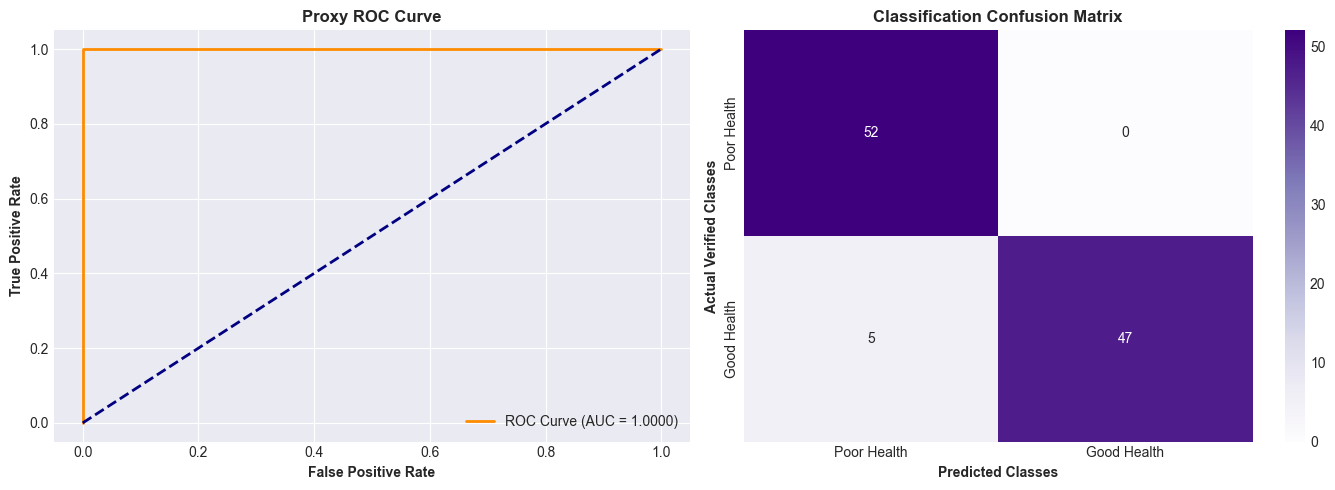

In [17]:
print("--- Binary Classification Conversion Metrics (ROC-AUC) ---")

# Define target partition using sample dataset median threshold
median_threshold = np.median(y_test)
y_test_binary = (y_test > median_threshold).astype(int)

y_pred_arr = np.asarray(y_pred).flatten()
# Normalize continuous regression outputs to pseudo-probabilities range [0, 1]
y_pred_norm = (y_pred_arr - y_pred_arr.min()) / (y_pred_arr.max() - y_pred_arr.min() + 1e-8)

fpr, tpr, _ = roc_curve(y_test_binary, y_pred_norm)
roc_auc_val = auc(fpr, tpr)
y_pred_binary_labels = (y_pred_norm > 0.5).astype(int)

print(f"↳ Established Performance Threshold Limit: {median_threshold:.5f}")
print(f"↳ Resulting Proxy ROC-AUC Score: {roc_auc_val:.4f}\n")
print(classification_report(y_test_binary, y_pred_binary_labels, target_names=['Poor Health', 'Good Health']))

# Generate plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('Proxy ROC Curve', fontweight='bold')
axes[0].legend(loc="lower right")

# Plot Confusion Matrix
cm = confusion_matrix(y_test_binary, y_pred_binary_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[1],
            xticklabels=['Poor Health', 'Good Health'], yticklabels=['Poor Health', 'Good Health'])
axes[1].set_xlabel('Predicted Classes', fontweight='bold')
axes[1].set_ylabel('Actual Verified Classes', fontweight='bold')
axes[1].set_title('Classification Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('classification_roc_auc_metrics.png', dpi=150, bbox_inches='tight')

--- Computing Global and Local Explanations using SHAP ---
✓ All global SHAP diagnostic plots generated successfully.


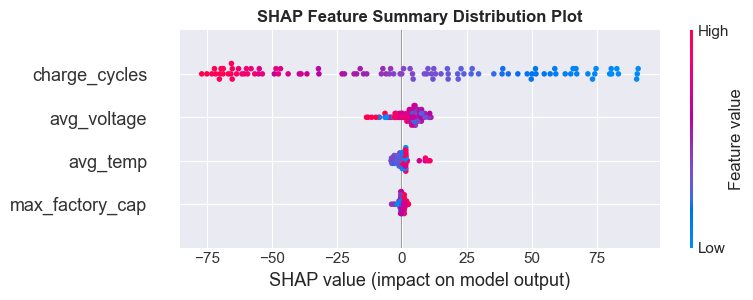

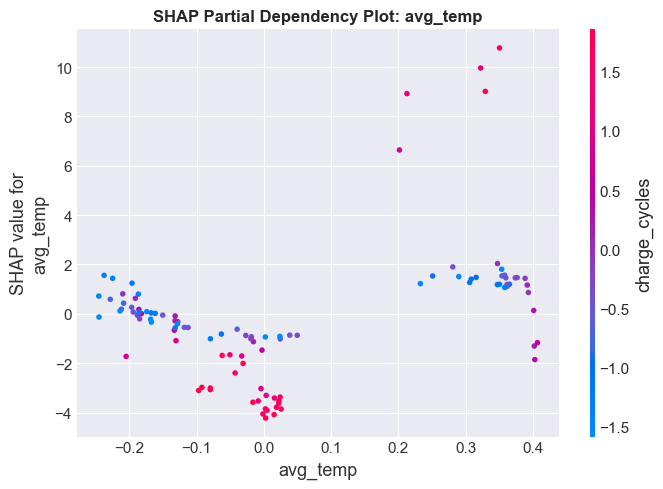

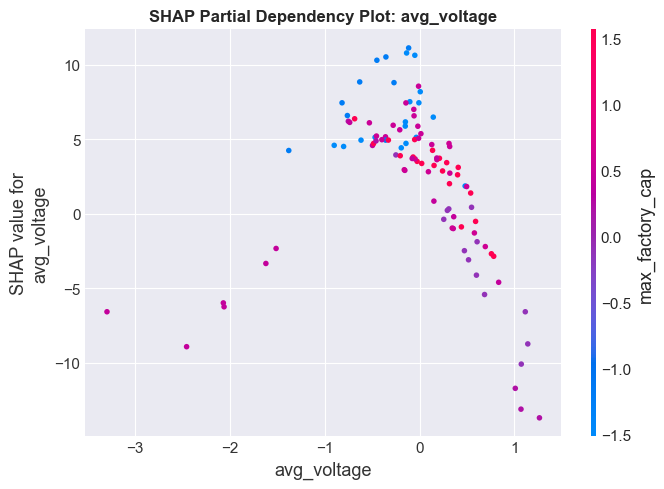

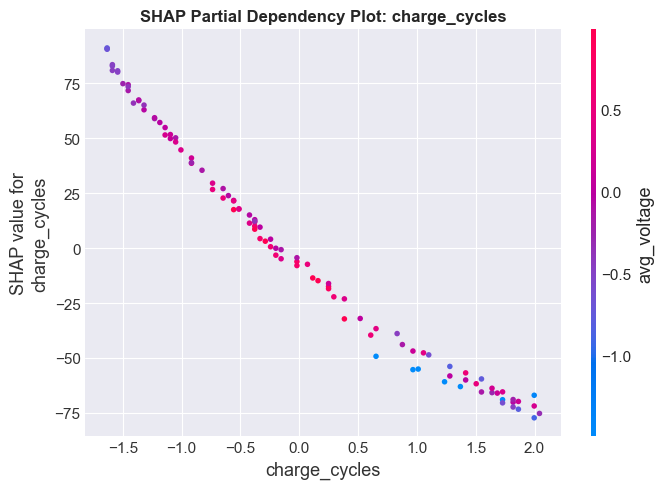

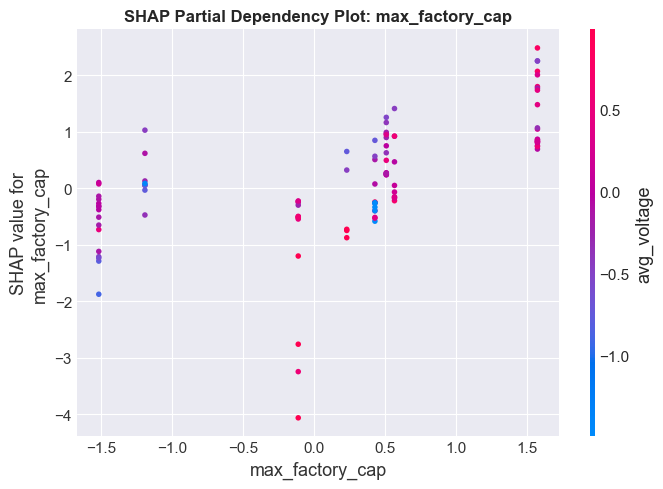

In [21]:
print("--- Computing Global and Local Explanations using SHAP ---")

# Extract standalone model and preprocessed data arrays using the pipeline structure
underlying_model = best_pipeline.named_steps['regressor']
X_train_scaled = best_pipeline.named_steps['scaler'].transform(X_train)
X_test_scaled = best_pipeline.named_steps['scaler'].transform(X_test)

# Convert back to dataframes to preserve feature tracking order names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=df_raw.columns.difference([TARGET, 'Cell_ID']))
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=df_raw.columns.difference([TARGET, 'Cell_ID']))

# Use generic or tree-based shap solvers depending on winner model class
if best_model_name in ['GradientBoosting', 'RandomForest']:
    shap_explainer = shap.TreeExplainer(underlying_model)
else:
    shap_explainer = shap.Explainer(underlying_model, X_train_scaled_df)

shap_values_matrix = shap_explainer.shap_values(X_test_scaled_df)

# 1. SHAP Summary Plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values_matrix, X_test_scaled_df, plot_type="dot", show=False)
plt.title("SHAP Feature Summary Distribution Plot", fontweight='bold')
plt.tight_layout()
plt.savefig('shap_global_summary.png', dpi=150, bbox_inches='tight')

# 2. Loop and generate Individual Feature Dependency Plots
for feature in X_test_scaled_df.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    shap.dependence_plot(feature, shap_values_matrix, X_test_scaled_df, show=False, ax=ax)
    plt.title(f'SHAP Partial Dependency Plot: {feature}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_dependency_{feature}.png', dpi=150, bbox_inches='tight')

print("✓ All global SHAP diagnostic plots generated successfully.")

--- Initializing Local Interpretable Model-agnostic Explanations (LIME) ---
✓ LIME subplots executed.


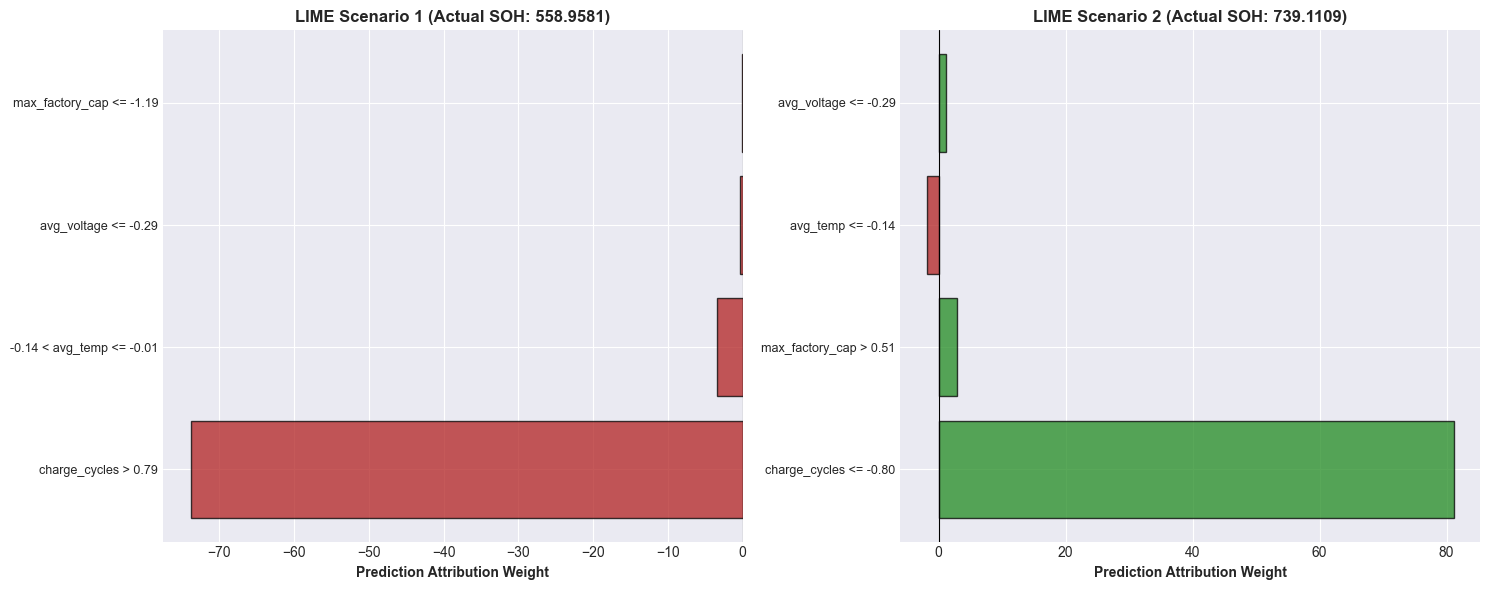

In [24]:
print("--- Initializing Local Interpretable Model-agnostic Explanations (LIME) ---")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X_train_scaled_df.columns.tolist(),
    class_names=[TARGET],
    mode='regression',
    random_state=42
)

# Benchmark 2 localized scenarios: Minimum SOH versus Maximum SOH records
extreme_samples = [np.argmin(y_test.values), np.argmax(y_test.values)]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes = axes.flatten()

for idx, target_index in enumerate(extreme_samples):
    instance_data = X_test_scaled_df.iloc[target_index].values
    
    lime_explanation = lime_explainer.explain_instance(
        data_row=instance_data,
        predict_fn=underlying_model.predict,
        num_features=len(X_test_scaled_df.columns)
    )
    
    features_contributions = lime_explanation.as_list()
    names = [item[0] for item in features_contributions]
    values = [item[1] for item in features_contributions]
    bar_colors = ['forestgreen' if val > 0 else 'firebrick' for val in values]
    
    y_positions = np.arange(len(names))
    axes[idx].barh(y_positions, values, color=bar_colors, alpha=0.75, edgecolor='black')
    axes[idx].set_yticks(y_positions)
    axes[idx].set_yticklabels(names, fontsize=9)
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[idx].set_xlabel('Prediction Attribution Weight', fontweight='bold')
    axes[idx].set_title(f"LIME Scenario {idx+1} (Actual SOH: {y_test.iloc[target_index]:.4f})", fontweight='bold')

plt.tight_layout()
plt.savefig('lime_local_explanations.png', dpi=150, bbox_inches='tight')
print("✓ LIME subplots executed.")

In [42]:
"""
Battery Health Predictor — CustomTkinter GUI  (v2)
Replaces Cell 10 of mine.ipynb.

Layout
------
  ┌─ Header (device name + scan button) ──────────────────────┐
  │ LEFT PANEL                  │ RIGHT PANEL                  │
  │  • Telemetry tiles          │  • Big health %              │
  │    (green = received,       │  • Progress arc label        │
  │     amber = needs input)    │  • SOH / scale / cap tiles   │
  │  • Manual entry fields      │  • Status verdict            │
  │    for missing values       │  • Audit log                 │
  │  • Predict button           │                              │
  └─────────────────────────────┴──────────────────────────────┘

Requirements:  pip install customtkinter
Run after notebook cells 1–9 (best_pipeline & df_raw in scope).
Set STANDALONE_MODE = True to test the UI without a trained model.
"""

import subprocess, threading, re, os, shutil
import numpy as np
import pandas as pd
import customtkinter as ctk
from tkinter import messagebox

# ── Mode ───────────────────────────────────────────────────────
STANDALONE_MODE = False   # flip True to run without a model

# ── Palette ────────────────────────────────────────────────────
ctk.set_appearance_mode("dark")
ctk.set_default_color_theme("blue")

BG      = "#0A0E14"
CARD    = "#13181F"
CARD2   = "#1A2030"
BORDER  = "#252D3A"
TEXT    = "#DDE6F0"
MUTED   = "#6B7A90"
ACCENT  = "#38BDF8"
GOOD    = "#34D399"
WARN    = "#FBBF24"
BAD     = "#F87171"
FILLED  = "#1E3A2F"   # tile bg when value was received from ADB
MISSING = "#2A1F0E"   # tile bg when value is missing / needs input


# ══════════════════════════════════════════════════════════════
#  ADB helpers
# ══════════════════════════════════════════════════════════════

def _adb_exe():
    path = shutil.which("adb")
    if not path:
        la = os.getenv("LOCALAPPDATA", "")
        candidate = os.path.join(la, "Android", "Sdk", "platform-tools", "adb.exe")
        if os.path.exists(candidate):
            path = candidate
    if path:
        try:
            subprocess.run([path, "start-server"], capture_output=True, timeout=5)
        except Exception:
            pass
    return path


def query_device(adb):
    """Return (device_id, device_model, metrics_dict, sources_dict)."""
    device_id = device_model = None
    metrics, sources = {}, {}

    if not adb:
        return device_id, device_model, metrics, sources

    # ── List devices ───────────────────────────────────────────
    try:
        out = subprocess.run([adb, "devices", "-l"],
                             capture_output=True, text=True, timeout=5).stdout
        for line in out.splitlines()[1:]:
            if "device" in line and not line.startswith("*"):
                parts = line.split()
                device_id = parts[0]
                # grab model token if present  e.g. model:Pixel_6
                for p in parts:
                    if p.startswith("model:"):
                        device_model = p[6:].replace("_", " ")
                break
    except Exception:
        pass

    if not device_id:
        return device_id, device_model, metrics, sources

    # ── dumpsys battery ────────────────────────────────────────
    try:
        dump = subprocess.run(
            [adb, "-s", device_id, "shell", "dumpsys", "battery"],
            capture_output=True, text=True, timeout=5).stdout

        v = re.search(r"^\s*voltage:\s*(\d+)", dump, re.I | re.M)
        if v:
            raw = float(v.group(1))
            # dumpsys always reports in mV (e.g. 5000 = 5.000 V); divide unconditionally
            metrics["voltage"] = raw / 1000.0
            sources["voltage"] = "ADB"

        t = re.search(r"temperature:\s*(\d+)", dump, re.I)
        if t:
            metrics["temperature"] = float(t.group(1)) / 10.0
            sources["temperature"] = "ADB"

        lvl = re.search(r"level:\s*(\d+)", dump, re.I)
        if lvl:
            metrics["charge_level"] = int(lvl.group(1))

        st = re.search(r"status:\s*(\d+)", dump, re.I)
        STATUS_MAP = {1:"Unknown",2:"Charging",3:"Discharging",4:"Not charging",5:"Full"}
        if st:
            metrics["charge_status"] = STATUS_MAP.get(int(st.group(1)), st.group(1))

        plug = re.search(r"plugged:\s*(\d+)", dump, re.I)
        PLUG_MAP = {0:"Unplugged",1:"AC",2:"USB",4:"Wireless"}
        if plug:
            metrics["plugged"] = PLUG_MAP.get(int(plug.group(1)), plug.group(1))

        health = re.search(r"health:\s*(\d+)", dump, re.I)
        HEALTH_MAP = {1:"Unknown",2:"Good",3:"Overheat",4:"Dead",5:"Over voltage",6:"Unspecified failure",7:"Cold"}
        if health:
            metrics["android_health"] = HEALTH_MAP.get(int(health.group(1)), health.group(1))

    except Exception:
        pass

    # ── getprop ────────────────────────────────────────────────
    try:
        props = subprocess.run(
            [adb, "-s", device_id, "shell", "getprop"],
            capture_output=True, text=True, timeout=5).stdout

        cap = re.search(r"(?:charge_full_design|capacity)[:\s]+(\d+)", props, re.I)
        if cap:
            metrics["factory_capacity"] = float(cap.group(1))
            sources["factory_capacity"] = "ADB"

        cyc = re.search(r"(?:cycle_count|battery\.cycle_count)[:\s]+(\d+)", props, re.I)
        if cyc and float(cyc.group(1)) > 0:
            metrics["charge_cycles"] = float(cyc.group(1))
            sources["charge_cycles"] = "ADB"

        brand = re.search(r"\[ro\.product\.brand\]:\s*\[(.+?)\]", props, re.I)
        model_prop = re.search(r"\[ro\.product\.model\]:\s*\[(.+?)\]", props, re.I)
        if brand and model_prop and not device_model:
            device_model = f"{brand.group(1).title()} {model_prop.group(1)}"
        elif model_prop and not device_model:
            device_model = model_prop.group(1)

        android = re.search(r"\[ro\.build\.version\.release\]:\s*\[(.+?)\]", props, re.I)
        if android:
            metrics["android_version"] = android.group(1)

    except Exception:
        pass

    # ── sysfs cycle fallback ───────────────────────────────────
    if "charge_cycles" not in metrics:
        for cmd in ["cat /sys/class/power_supply/bms/cycle_count",
                    "cat /sys/class/power_supply/battery/cycle_count"]:
            try:
                r = subprocess.run([adb, "-s", device_id, "shell", cmd],
                                   capture_output=True, text=True, timeout=3)
                if r.returncode == 0 and r.stdout.strip().isdigit():
                    val = float(r.stdout.strip())
                    if val > 0:
                        metrics["charge_cycles"] = val
                        sources["charge_cycles"] = "ADB"
                        break
            except Exception:
                pass

    return device_id, device_model, metrics, sources


# ══════════════════════════════════════════════════════════════
#  Inference
# ══════════════════════════════════════════════════════════════

def run_inference(voltage, temperature, factory_capacity, charge_cycles):
    if STANDALONE_MODE:
        import random
        tmax = 739.11
        pred = tmax * random.uniform(0.55, 0.99)
        return pred, (pred / tmax) * 100, tmax

    tmax = df_raw["max_factory_cap"].max()
    feats = best_pipeline.named_steps["scaler"].feature_names_in_.tolist()
    mapped = {}
    for f in feats:
        if "cycle" in f:   mapped[f] = charge_cycles
        elif "volt" in f:  mapped[f] = voltage
        elif "temp" in f:  mapped[f] = temperature
        elif "cap" in f:   mapped[f] = tmax        # training scale, not phone cap
    df_in = pd.DataFrame([mapped])[feats]
    pred = best_pipeline.predict(df_in)[0]
    pct  = float(np.clip((pred / tmax) * 100, 0, 100))
    return pred, pct, tmax


# ══════════════════════════════════════════════════════════════
#  App
# ══════════════════════════════════════════════════════════════

class BatteryApp(ctk.CTk):

    # ── Required inputs ────────────────────────────────────────
    REQUIRED = ["voltage", "temperature", "factory_capacity", "charge_cycles"]

    def __init__(self):
        super().__init__()
        self.title("Battery Health Predictor")
        self.geometry("980x700")
        self.minsize(900, 620)
        self.configure(fg_color=BG)

        self._metrics  = {}
        self._sources  = {}
        self._device_id    = None
        self._device_model = None

        self._entry_vars   = {}   # key → StringVar  (for missing fields)
        self._tile_widgets = {}   # key → (frame, value_label)

        self._build_ui()

    # ══════════════════════════════════════════
    #  UI skeleton
    # ══════════════════════════════════════════

    def _build_ui(self):
        # ── Header ────────────────────────────
        hdr = ctk.CTkFrame(self, fg_color=CARD, corner_radius=0, height=60)
        hdr.pack(fill="x")
        hdr.pack_propagate(False)

        ctk.CTkLabel(hdr, text="🔋  Battery Health Predictor",
                     font=ctk.CTkFont("Consolas", 19, "bold"),
                     text_color=ACCENT).pack(side="left", padx=22, pady=12)

        # scan button lives in header
        self._scan_btn = ctk.CTkButton(
            hdr, text="⚡  Connect Device", width=170, height=34,
            font=ctk.CTkFont("Consolas", 12, "bold"),
            fg_color=CARD2, hover_color="#1E293B",
            border_color=ACCENT, border_width=1,
            text_color=ACCENT,
            command=self._on_scan)
        self._scan_btn.pack(side="right", padx=20, pady=12)

        # device name pill (right of scan btn)
        self._device_label = ctk.CTkLabel(
            hdr, text="No device connected",
            font=ctk.CTkFont("Consolas", 12),
            text_color=MUTED)
        self._device_label.pack(side="right", padx=(0, 6))

        # ── Body: two columns ─────────────────
        body = ctk.CTkFrame(self, fg_color=BG)
        body.pack(fill="both", expand=True, padx=16, pady=12)
        body.columnconfigure(0, weight=3)
        body.columnconfigure(1, weight=2)
        body.rowconfigure(0, weight=1)

        self._build_left(body)
        self._build_right(body)

    # ── LEFT panel ─────────────────────────────────────────────

    def _build_left(self, parent):
        left = ctk.CTkScrollableFrame(parent, fg_color=BG,
                                      scrollbar_button_color=BORDER,
                                      scrollbar_button_hover_color=ACCENT)
        left.grid(row=0, column=0, sticky="nsew", padx=(0, 8))

        # ── Telemetry tiles grid ───────────────
        self._tiles_label = ctk.CTkLabel(
            left, text="DEVICE TELEMETRY",
            font=ctk.CTkFont("Consolas", 10, "bold"),
            text_color=MUTED)
        self._tiles_label.pack(anchor="w", padx=4, pady=(0, 6))

        tiles_frame = ctk.CTkFrame(left, fg_color="transparent")
        tiles_frame.pack(fill="x")
        tiles_frame.columnconfigure((0, 1, 2), weight=1)

        # All possible telemetry fields (order determines grid position)
        self._all_fields = [
            ("voltage",          "⚡ Voltage",       "V",   "e.g. 3.85"),
            ("temperature",      "🌡 Temperature",   "°C",  "e.g. 31.0"),
            ("factory_capacity", "🏭 Design Cap",    "mAh", "e.g. 5000"),
            ("charge_cycles",    "🔄 Charge Cycles", "",    "e.g. 350"),
            ("charge_level",     "🔋 Charge Level",  "%",   None),
            ("charge_status",    "⚙ Status",         "",    None),
            ("android_health",   "💚 Health Tag",    "",    None),
            ("plugged",          "🔌 Power Source",  "",    None),
            ("android_version",  "🤖 Android Ver",   "",    None),
        ]

        for idx, (key, label, unit, placeholder) in enumerate(self._all_fields):
            row_i = idx // 3
            col_i = idx  % 3
            tile = self._make_tile(tiles_frame, key, label, unit, placeholder)
            tile.grid(row=row_i, column=col_i, sticky="nsew", padx=4, pady=4)

        # ── Separator ─────────────────────────
        ctk.CTkFrame(left, height=1, fg_color=BORDER).pack(fill="x", pady=14)

        # ── Manual entry section ───────────────
        self._manual_title = ctk.CTkLabel(
            left,
            text="MANUAL ENTRY  —  fill in fields not received from device",
            font=ctk.CTkFont("Consolas", 10, "bold"),
            text_color=MUTED)
        self._manual_title.pack(anchor="w", padx=4, pady=(0, 8))

        self._manual_frame = ctk.CTkFrame(left, fg_color="transparent")
        self._manual_frame.pack(fill="x")
        self._manual_frame.columnconfigure((0, 1), weight=1)

        # Build entry rows for the 4 required inputs
        self._entry_rows = {}   # key → frame (so we can show/hide)
        req_fields = [(k, l, u, p) for k, l, u, p in self._all_fields
                      if k in self.REQUIRED]
        for i, (key, label, unit, placeholder) in enumerate(req_fields):
            var = ctk.StringVar()
            self._entry_vars[key] = var
            row_frame = self._make_entry_row(
                self._manual_frame, i // 2, i % 2,
                label + (f" ({unit})" if unit else ""),
                var, placeholder or "")
            self._entry_rows[key] = row_frame

        # Days estimate toggle — lives inside manual_frame as a third row spanning both cols
        self._cycle_mode = ctk.StringVar(value="direct")
        self._days_var   = ctk.StringVar()
        self._build_days_toggle(self._manual_frame)

        # ── Predict button ─────────────────────
        ctk.CTkFrame(left, height=1, fg_color=BORDER).pack(fill="x", pady=14)

        self._predict_btn = ctk.CTkButton(
            left, text="▶  Predict Battery Health", height=46,
            font=ctk.CTkFont("Consolas", 14, "bold"),
            fg_color=ACCENT, hover_color="#0EA5E9",
            text_color="#000D18", corner_radius=8,
            command=self._on_predict)
        self._predict_btn.pack(fill="x", padx=4, pady=(0, 4))

        self._predict_status = ctk.CTkLabel(
            left, text="Connect a device or fill fields manually, then predict.",
            font=ctk.CTkFont("Consolas", 10), text_color=MUTED)
        self._predict_status.pack(pady=(2, 10))

    def _make_tile(self, parent, key, label, unit, placeholder):
        """A coloured tile. Starts grey (no data). Green = received, amber = needs input."""
        needs_input = key in self.REQUIRED

        frame = ctk.CTkFrame(parent, fg_color=CARD, corner_radius=8,
                             border_color=BORDER, border_width=1)

        ctk.CTkLabel(frame, text=label,
                     font=ctk.CTkFont("Consolas", 9, "bold"),
                     text_color=MUTED).pack(anchor="w", padx=10, pady=(8, 2))

        val_label = ctk.CTkLabel(frame, text="—",
                                 font=ctk.CTkFont("Consolas", 16, "bold"),
                                 text_color=MUTED)
        val_label.pack(anchor="w", padx=10)

        src_label = ctk.CTkLabel(frame, text="awaiting" if needs_input else "n/a",
                                 font=ctk.CTkFont("Consolas", 8),
                                 text_color=MUTED)
        src_label.pack(anchor="w", padx=10, pady=(1, 8))

        self._tile_widgets[key] = (frame, val_label, src_label)
        return frame

    def _make_entry_row(self, parent, row, col, label, var, placeholder):
        frame = ctk.CTkFrame(parent, fg_color="transparent")
        frame.grid(row=row, column=col, sticky="ew", padx=5, pady=5)
        frame.columnconfigure(0, weight=1)
        ctk.CTkLabel(frame, text=label,
                     font=ctk.CTkFont("Consolas", 10), text_color=MUTED
                     ).grid(row=0, column=0, sticky="w")
        ctk.CTkEntry(frame, textvariable=var, placeholder_text=placeholder,
                     font=ctk.CTkFont("Consolas", 13), height=36,
                     fg_color=CARD2, border_color=BORDER,
                     text_color=TEXT, corner_radius=6
                     ).grid(row=1, column=0, sticky="ew", pady=(3, 0))
        return frame

    def _build_days_toggle(self, manual_frame):
        # Toggle row spans both columns (row 2, below voltage/temp and cap/cycles)
        toggle_frame = ctk.CTkFrame(manual_frame, fg_color="transparent")
        toggle_frame.grid(row=2, column=0, columnspan=2, sticky="ew", padx=5, pady=(6, 2))

        ctk.CTkSwitch(
            toggle_frame,
            text="  Estimate charge cycles from days used instead",
            variable=self._cycle_mode, onvalue="days", offvalue="direct",
            font=ctk.CTkFont("Consolas", 10), text_color=MUTED,
            progress_color=ACCENT,
            command=self._on_cycle_toggle
        ).pack(side="left")

        # Days entry row — same grid slot as charge_cycles row (row 1, col 1)
        # Hidden by default; shown when toggle is ON
        self._days_row = ctk.CTkFrame(manual_frame, fg_color="transparent")
        self._days_row.columnconfigure(0, weight=1)
        ctk.CTkLabel(self._days_row,
                     text="📅 Days Used (cycles estimated as days × 1.25)",
                     font=ctk.CTkFont("Consolas", 10), text_color=WARN
                     ).grid(row=0, column=0, sticky="w")
        ctk.CTkEntry(self._days_row, textvariable=self._days_var,
                     placeholder_text="e.g. 400",
                     font=ctk.CTkFont("Consolas", 13), height=36,
                     fg_color=CARD2, border_color=WARN,
                     text_color=TEXT, corner_radius=6
                     ).grid(row=1, column=0, sticky="ew", pady=(3, 0))
        # Don't grid it yet — shown on toggle

    def _on_cycle_toggle(self):
        if self._cycle_mode.get() == "days":
            # Hide cycles entry row, show days row in its place
            self._entry_rows["charge_cycles"].grid_remove()
            self._days_row.grid(row=1, column=1, sticky="ew", padx=5, pady=5)
            # Update the cycles tile to reflect estimation mode
            frame, val_lbl, src_lbl = self._tile_widgets["charge_cycles"]
            val_lbl.configure(text="from days", text_color=WARN)
            src_lbl.configure(text="estimated", text_color=WARN)
            frame.configure(fg_color=MISSING, border_color=WARN)
        else:
            # Hide days row, restore cycles entry row
            self._days_row.grid_remove()
            self._entry_rows["charge_cycles"].grid(row=1, column=1, sticky="ew", padx=5, pady=5)
            # Reset cycles tile back to needs-input state if not in metrics
            frame, val_lbl, src_lbl = self._tile_widgets["charge_cycles"]
            if "charge_cycles" not in self._metrics:
                val_lbl.configure(text="needs input", text_color=WARN)
                src_lbl.configure(text="manual required", text_color=WARN)
                frame.configure(fg_color=MISSING, border_color=WARN)

    # ── RIGHT panel ────────────────────────────────────────────

    def _build_right(self, parent):
        right = ctk.CTkFrame(parent, fg_color=CARD, corner_radius=12,
                             border_color=BORDER, border_width=1)
        right.grid(row=0, column=1, sticky="nsew")

        ctk.CTkLabel(right, text="PREDICTED HEALTH",
                     font=ctk.CTkFont("Consolas", 10, "bold"),
                     text_color=MUTED).pack(anchor="w", padx=20, pady=(18, 4))

        ctk.CTkFrame(right, height=1, fg_color=BORDER).pack(fill="x", padx=20)

        # Big % number
        self._big_pct = ctk.CTkLabel(right, text="—",
                                     font=ctk.CTkFont("Consolas", 68, "bold"),
                                     text_color=MUTED)
        self._big_pct.pack(pady=(28, 0))

        self._verdict = ctk.CTkLabel(right, text="Run a prediction",
                                     font=ctk.CTkFont("Consolas", 13),
                                     text_color=MUTED)
        self._verdict.pack(pady=(4, 16))

        # Progress bar
        self._bar = ctk.CTkProgressBar(right, height=12, corner_radius=6,
                                       progress_color=MUTED, fg_color=BORDER)
        self._bar.set(0)
        self._bar.pack(fill="x", padx=24, pady=(0, 22))

        # Three stat tiles
        stat_row = ctk.CTkFrame(right, fg_color="transparent")
        stat_row.pack(fill="x", padx=16)
        stat_row.columnconfigure((0, 1, 2), weight=1)

        self._stat_pred   = self._make_stat(stat_row, 0, "Predicted SOH")
        self._stat_scale  = self._make_stat(stat_row, 1, "Train Scale")
        self._stat_device = self._make_stat(stat_row, 2, "Device Cap")

        ctk.CTkFrame(right, height=1, fg_color=BORDER).pack(fill="x", padx=20, pady=18)

        # Audit log
        ctk.CTkLabel(right, text="TELEMETRY LOG",
                     font=ctk.CTkFont("Consolas", 9, "bold"),
                     text_color=MUTED).pack(anchor="w", padx=20, pady=(0, 4))

        self._log = ctk.CTkTextbox(
            right, font=ctk.CTkFont("Consolas", 10),
            fg_color=BG, border_color=BORDER, border_width=1,
            text_color=MUTED, corner_radius=6, state="disabled")
        self._log.pack(fill="both", expand=True, padx=16, pady=(0, 16))

        self._log_write("Connect a device or fill fields manually,\nthen press Predict.\n")

    def _make_stat(self, parent, col, label):
        f = ctk.CTkFrame(parent, fg_color=CARD2, corner_radius=8)
        f.grid(row=0, column=col, sticky="ew", padx=3, pady=4)
        ctk.CTkLabel(f, text=label, font=ctk.CTkFont("Consolas", 8, "bold"),
                     text_color=MUTED).pack(pady=(8, 2))
        v = ctk.CTkLabel(f, text="—", font=ctk.CTkFont("Consolas", 13, "bold"),
                         text_color=TEXT)
        v.pack(pady=(0, 8))
        return v

    # ══════════════════════════════════════════
    #  ADB scan
    # ══════════════════════════════════════════

    def _on_scan(self):
        self._scan_btn.configure(state="disabled", text="Scanning…")
        self._device_label.configure(text="Looking for device…", text_color=MUTED)
        threading.Thread(target=self._scan_worker, daemon=True).start()

    def _scan_worker(self):
        adb = _adb_exe()
        dev_id, dev_model, metrics, sources = query_device(adb)
        self.after(0, self._scan_done, dev_id, dev_model, metrics, sources)

    def _scan_done(self, dev_id, dev_model, metrics, sources):
        self._scan_btn.configure(state="normal", text="⚡  Connect Device")

        if not dev_id:
            self._device_label.configure(
                text="⚠  No device found", text_color=WARN)
            self._log_write("No ADB device detected.\nEnsure USB debugging is enabled.\n")
            return

        self._device_id    = dev_id
        self._device_model = dev_model
        self._metrics  = metrics
        self._sources  = sources

        display_name = dev_model or dev_id
        android_ver  = metrics.get("android_version", "")
        badge = f"📱  {display_name}" + (f"  ·  Android {android_ver}" if android_ver else "")
        self._device_label.configure(text=badge, text_color=GOOD)

        # Update tiles
        for key, label, unit, placeholder in self._all_fields:
            if key not in self._tile_widgets:
                continue
            frame, val_lbl, src_lbl = self._tile_widgets[key]

            if key in metrics:
                val = metrics[key]
                fmt = f"{val:.3f}" if isinstance(val, float) and key == "voltage" \
                    else f"{val:.1f}" if isinstance(val, float) \
                    else str(val)
                display = fmt + (f" {unit}" if unit else "")

                val_lbl.configure(text=display, text_color=GOOD)
                src_lbl.configure(text=sources.get(key, "ADB"), text_color=GOOD)
                frame.configure(fg_color=FILLED, border_color=GOOD)

                # Pre-fill entry var too
                if key in self._entry_vars:
                    self._entry_vars[key].set(fmt)
            else:
                # Not received
                if key in self.REQUIRED:
                    val_lbl.configure(text="needs input", text_color=WARN)
                    src_lbl.configure(text="manual required", text_color=WARN)
                    frame.configure(fg_color=MISSING, border_color=WARN)
                else:
                    val_lbl.configure(text="unavailable", text_color=MUTED)
                    src_lbl.configure(text="not exposed", text_color=MUTED)
                    frame.configure(fg_color=CARD, border_color=BORDER)

        # Update manual entries visibility
        received_required = [k for k in self.REQUIRED if k in metrics]
        missing_required  = [k for k in self.REQUIRED if k not in metrics]

        if not missing_required:
            self._manual_title.configure(
                text="✅  All required values received from device.",
                text_color=GOOD)
        else:
            names = ", ".join(missing_required)
            self._manual_title.configure(
                text=f"⚠  Enter manually:  {names}",
                text_color=WARN)

        # Log
        lines = [f"Device   : {display_name}  [{dev_id}]"]
        if android_ver:
            lines.append(f"Android  : {android_ver}")
        lines.append("")
        lines.append("── Received ──────────────────────")
        for k in self.REQUIRED:
            src = sources.get(k, "—")
            val = metrics.get(k)
            status = f"{val}  [{src}]" if val is not None else "NOT RECEIVED"
            lines.append(f"  {k:<20} {status}")
        self._log_write("\n".join(lines) + "\n")

    # ══════════════════════════════════════════
    #  Predict
    # ══════════════════════════════════════════

    def _on_predict(self):
        vals = {}

        # ── Resolve charge_cycles first (mode-dependent) ───────
        if self._cycle_mode.get() == "days":
            raw_days = self._days_var.get().strip()
            if not raw_days:
                messagebox.showerror("Missing Input",
                    "Days used is empty. Enter a number of days or switch back to direct cycle input.")
                return
            try:
                days = float(raw_days)
                vals["charge_cycles"] = float(np.clip(days * 1.25, 0, 8200))
            except ValueError:
                messagebox.showerror("Invalid Input", f"Days used must be a number. Got: {raw_days!r}")
                return
        # (direct mode — handled in the main loop below)

        # ── Gather remaining required values ───────────────────
        for key in self.REQUIRED:
            if key == "charge_cycles" and "charge_cycles" in vals:
                continue   # already resolved above via days
            if key in self._metrics:
                vals[key] = self._metrics[key]
            else:
                raw = self._entry_vars[key].get().strip()
                if not raw:
                    messagebox.showerror("Missing Input",
                        f"'{key}' was not received from the device and has not been filled in.")
                    return
                try:
                    vals[key] = float(raw)
                except ValueError:
                    messagebox.showerror("Invalid Input",
                        f"'{key}' must be a number. Got: {raw!r}")
                    return

        # Voltage mV guard — only needed if typed manually (ADB already converts at scan time)
        if "voltage" not in self._metrics and vals["voltage"] > 10.0:
            vals["voltage"] /= 1000.0

        self._predict_btn.configure(state="disabled", text="Running…")
        self._predict_status.configure(text="⏳  Running inference…", text_color=MUTED)

        def worker():
            pred, pct, tmax = run_inference(
                vals["voltage"], vals["temperature"],
                vals["factory_capacity"], vals["charge_cycles"])
            self.after(0, self._show_results, pred, pct, tmax, vals)

        threading.Thread(target=worker, daemon=True).start()

    def _show_results(self, pred, pct, tmax, vals):
        self._predict_btn.configure(state="normal", text="▶  Predict Battery Health")

        color  = GOOD if pct >= 80 else WARN if pct >= 60 else BAD
        emoji  = "✅" if pct >= 80 else "⚠️" if pct >= 60 else "❌"
        status = ("Good — battery is healthy."
                  if pct >= 80 else
                  "Fair — degradation is noticeable."
                  if pct >= 60 else
                  "Poor — consider replacing the battery.")

        self._big_pct.configure(text=f"{pct:.1f}%", text_color=color)
        self._verdict.configure(text=f"{emoji}  {status}", text_color=color)
        self._bar.configure(progress_color=color)
        self._bar.set(pct / 100)

        self._stat_pred.configure(text=f"{pred:.1f} mAh")
        self._stat_scale.configure(text=f"{tmax:.1f} mAh")
        self._stat_device.configure(text=f"{vals['factory_capacity']:.0f} mAh")

        self._predict_status.configure(text="✓  Prediction complete.", text_color=GOOD)

        # Build audit log
        src = self._sources
        dev = self._device_model or self._device_id or "Manual"
        lines = [
            "── Inference Input Log ──────────────────",
            f"  Device             {dev}",
            f"  Voltage            {vals['voltage']:.3f} V   [{src.get('voltage','MANUAL')}]",
            f"  Temperature        {vals['temperature']:.1f} °C  [{src.get('temperature','MANUAL')}]",
            f"  Factory Cap        {vals['factory_capacity']:.0f} mAh [{src.get('factory_capacity','MANUAL')}]",
            f"  Charge Cycles      {vals['charge_cycles']:.0f}     [{src.get('charge_cycles','MANUAL')}]",
            "─────────────────────────────────────────",
            f"  Predicted SOH      {pred:.2f} mAh",
            f"  Training Scale     {tmax:.2f} mAh",
            f"  Health %           {pct:.2f}%",
            "",
            "  ⚠ Health uses training-scale denominator",
            f"    ({tmax:.1f} mAh), not device factory cap.",
        ]
        self._log_write("\n".join(lines) + "\n")

    # ── Helpers ────────────────────────────────────────────────

    def _log_write(self, text):
        self._log.configure(state="normal")
        self._log.delete("0.0", "end")
        self._log.insert("0.0", text)
        self._log.configure(state="disabled")


# ══════════════════════════════════════════════════════════════
#  Entry point
# ══════════════════════════════════════════════════════════════

app = BatteryApp()
app.mainloop()